In [116]:
!pip install -q nltk

In [120]:
#IMPORT LIBRARIES
import pandas as pd
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [122]:
#LOAD DATASET
df = pd.read_csv("hotel-reviews.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Reviews:")
print(df.head())

Dataset Shape: (38932, 5)

Columns:
['User_ID', 'Description', 'Browser_Used', 'Device_Used', 'Is_Response']

First 5 Reviews:
   User_ID                                        Description  \
0  id10326  The room was kind of clean but had a VERY stro...   
1  id10327  I stayed at the Crown Plaza April -- - April -...   
2  id10328  I booked this hotel through Hotwire at the low...   
3  id10329  Stayed here with husband and sons on the way t...   
4  id10330  My girlfriends and I stayed here to celebrate ...   

        Browser_Used Device_Used Is_Response  
0               Edge      Mobile   not happy  
1  Internet Explorer      Mobile   not happy  
2            Mozilla      Tablet   not happy  
3   InternetExplorer     Desktop       happy  
4               Edge      Tablet   not happy  


In [123]:
# SELECT REQUIRED COLUMNS
df = df[[
    "Description",
    "Is_Response"
]]

df.columns = [
    "review",
    "sentiment"
]

print("\nSelected Data:")
print(df.head())


Selected Data:
                                              review  sentiment
0  The room was kind of clean but had a VERY stro...  not happy
1  I stayed at the Crown Plaza April -- - April -...  not happy
2  I booked this hotel through Hotwire at the low...  not happy
3  Stayed here with husband and sons on the way t...      happy
4  My girlfriends and I stayed here to celebrate ...  not happy


In [124]:
#REMOVE MISSING VALUES
df = df.dropna(
    subset=[
        "review",
        "sentiment"
    ]
)

df["review"] = df["review"].astype(str)

df["sentiment"] = (
    df["sentiment"]
    .astype(str)
    .str.lower()
    .str.strip()
)

print("\nDataset Size:")
print(df.shape)

print("\nSentiment Distribution:")
print(df["sentiment"].value_counts())



Dataset Size:
(38932, 2)

Sentiment Distribution:
sentiment
happy        26521
not happy    12411
Name: count, dtype: int64


In [125]:
#TEXT PREPROCESSING
stop_words = set(
    stopwords.words("english")
)

lemmatizer = WordNetLemmatizer()


def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(
        r"http\S+|www\S+",
        " ",
        text
    )

    # Remove numbers
    text = re.sub(
        r"\d+",
        " ",
        text
    )

    # Remove punctuation
    text = re.sub(
        r"[^a-zA-Z\s]",
        " ",
        text
    )

    # Split into words
    words = text.split()

    # Remove stopwords
    words = [
        word
        for word in words
        if word not in stop_words
    ]

    # Lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]

    return " ".join(words)


# Clean all reviews
df["clean_review"] = df["review"].apply(
    clean_text
)

print("\nCleaned Reviews:")
print(
    df[
        ["review", "clean_review"]
    ].head()
)



Cleaned Reviews:
                                              review  \
0  The room was kind of clean but had a VERY stro...   
1  I stayed at the Crown Plaza April -- - April -...   
2  I booked this hotel through Hotwire at the low...   
3  Stayed here with husband and sons on the way t...   
4  My girlfriends and I stayed here to celebrate ...   

                                        clean_review  
0  room kind clean strong smell dog generally ave...  
1  stayed crown plaza april april staff friendly ...  
2  booked hotel hotwire lowest price could find g...  
3  stayed husband son way alaska cruise loved hot...  
4  girlfriend stayed celebrate th birthday planne...  


In [ ]:
#CONVERT HAPPY / NOT HAPPY TO NUMBERS
df["label"] = df["sentiment"].map({
    "not happy": 0,
    "happy": 1
})

print("\nLabels:")
print(df["label"].value_counts())

In [128]:
#DEFINE INPUT AND OUTPUT
df["label"] = df["sentiment"].map({
    "not happy": 0,
    "happy": 1
})

X = df["clean_review"]
y = df["label"]

In [129]:
#TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("\nTraining Reviews:", len(X_train))
print("Testing Reviews:", len(X_test))


Training Reviews: 27252
Testing Reviews: 11680


In [130]:
#TF-IDF
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(
    X_train
)

X_test_tfidf = tfidf.transform(
    X_test
)

print("\nTF-IDF Complete")
print(
    "Training Shape:",
    X_train_tfidf.shape
)


TF-IDF Complete
Training Shape: (27252, 10000)


In [131]:
#TRAIN LOGISTIC REGRESSION
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

model.fit(
    X_train_tfidf,
    y_train
)

print("\nModel Training Completed!")


Model Training Completed!


In [134]:
# PREDICTION
y_pred = model.predict(
    X_test_tfidf
)

In [135]:
#MODEL PERFORMANCE
print("\n==============================")
print("MODEL PERFORMANCE")
print("==============================")

print(
    "Accuracy:",
    round(
        accuracy_score(
            y_test,
            y_pred
        ),
        4
    )
)

print(
    "Precision:",
    round(
        precision_score(
            y_test,
            y_pred
        ),
        4
    )
)

print(
    "Recall:",
    round(
        recall_score(
            y_test,
            y_pred
        ),
        4
    )
)

print(
    "F1 Score:",
    round(
        f1_score(
            y_test,
            y_pred
        ),
        4
    )
)


MODEL PERFORMANCE
Accuracy: 0.8834
Precision: 0.9326
Recall: 0.8934
F1 Score: 0.9126


In [136]:
#CLASSIFICATION REPORT
print("\n==============================")
print("CLASSIFICATION REPORT")
print("==============================")

print(
    classification_report(
        y_test,
        y_pred,
        labels=[0, 1],
        target_names=[
            "Not Happy",
            "Happy"
        ],
        zero_division=0
    )
)


CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Not Happy       0.79      0.86      0.82      3723
       Happy       0.93      0.89      0.91      7957

    accuracy                           0.88     11680
   macro avg       0.86      0.88      0.87     11680
weighted avg       0.89      0.88      0.88     11680



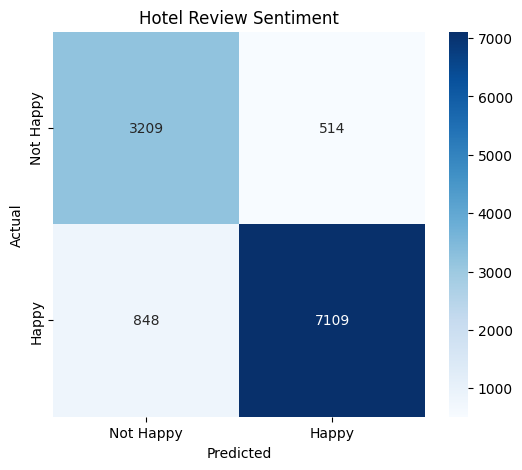

In [137]:
#CONFUSION MATRIX
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(
    figsize=(6, 5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Not Happy",
        "Happy"
    ],
    yticklabels=[
        "Not Happy",
        "Happy"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Hotel Review Sentiment")

plt.show()

In [140]:
# REVIEW BOX WITH RESULT
import ipywidgets as widgets
from IPython.display import display

# Create review input box
review_box = widgets.Textarea(
    placeholder="Enter your hotel review here...",
    description="Review:",
    layout=widgets.Layout(
        width="700px",
        height="120px"
    )
)

# Create prediction button
button = widgets.Button(
    description="Predict Sentiment",
    button_style="primary"
)

# Create result box
result_box = widgets.HTML(
    value="",
    layout=widgets.Layout(
        width="700px"
    )
)

# Prediction function
def predict_review(b):

    review = review_box.value

    if not review.strip():
        result_box.value = "<b>Please enter a hotel review.</b>"
        return

    # Clean review
    cleaned = clean_text(review)

    # Convert to TF-IDF
    review_tfidf = tfidf.transform([cleaned])

    # Predict
    prediction = model.predict(review_tfidf)[0]

    # Display result
    if prediction == 1:
        result = "😊 HAPPY"
    else:
        result = "😞 NOT HAPPY"

    result_box.value = (
        "<h3>Predicted Sentiment: "
        + result +
        "</h3>"
    )

# Connect button
button.on_click(predict_review)

# Display everything together
display(
    review_box,
    button,
    result_box
)

Textarea(value='', description='Review:', layout=Layout(height='120px', width='700px'), placeholder='Enter you…

Button(button_style='primary', description='Predict Sentiment', style=ButtonStyle())

HTML(value='', layout=Layout(width='700px'))